<a href="https://colab.research.google.com/github/MINHDUC-md/cophieu/blob/main/phantichcamxuc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import các thư viện cần thiết
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV

In [ ]:

import joblib

In [ ]:
#tạo quyền truy cập với google drive
from google.colab import drive
drive.mount('/content/drive')
# Đọc dữ liệu từ tệp CSV
data = pd.read_csv('/content/drive/MyDrive/MyDrive/IMDB Dataset.csv/IMDB Dataset.csv')

Mounted at /content/drive


In [ ]:
# Kiểm tra thông tin dữ liệu
print(f'Total records: {len(data)}')
print(f'Missing values in the dataset: \n{data.isnull().sum()}')

Total records: 50000
Missing values in the dataset: 
review       0
sentiment    0
dtype: int64


In [ ]:
# Kiểm tra các giá trị duy nhất trong cột sentiment
print(f'Unique sentiment labels: {data["sentiment"].unique()}')

Unique sentiment labels: ['positive' 'negative']


In [ ]:
# Tiền xử lý dữ liệu: Chuyển nhãn cảm xúc thành số
le = LabelEncoder()
data['sentiment'] = le.fit_transform(data['sentiment'])

In [ ]:
# Chia dữ liệu thành X (review) và y (sentiment)
X = data['review']
y = data['sentiment']

In [ ]:
# Chia dữ liệu thành tập huấn luyện và kiểm tra
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
# Biểu diễn văn bản bằng TF-IDF
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [ ]:
# Khám phá số lượng từ trong tập huấn luyện
print(f'Number of features (words) in the training set: {X_train_tfidf.shape[1]}')

Number of features (words) in the training set: 5000


In [ ]:

# Xây dựng mô hình học máy Naive Bayes
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

MultinomialNB()

In [ ]:
# 4. Lưu mô hình và vectorizer để sử dụng sau này
joblib.dump(model, 'sentiment_model.pkl')
joblib.dump(vectorizer, 'vectorizer.pkl')

['vectorizer.pkl']

In [ ]:
# Dự đoán trên tập kiểm tra
y_pred = model.predict(X_test_tfidf)

In [ ]:
# Đánh giá mô hình
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')
print(f'Classification Report:\n{classification_report(y_test, y_pred)}')

Accuracy: 0.8508
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.85      0.85      4961
           1       0.85      0.85      0.85      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



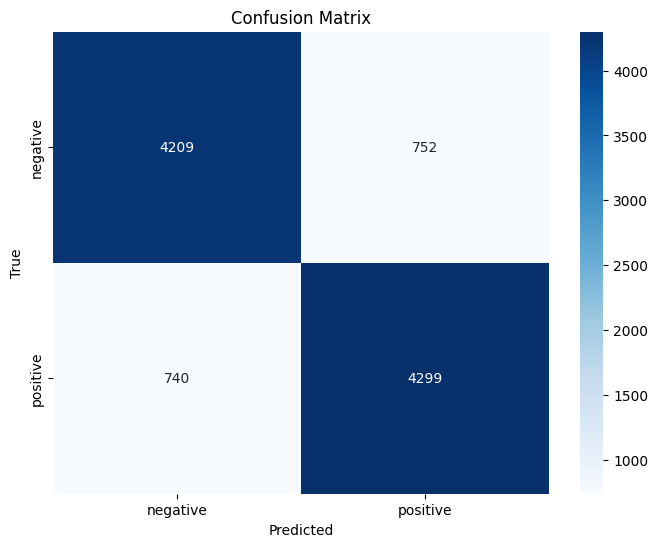

In [ ]:
# Ma trận nhầm lẫn
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Tuning the model using GridSearchCV
# Sử dụng GridSearch để tìm hyperparameters tối ưu cho Naive Bayes
param_grid = {'alpha': [0.1, 0.5, 1.0, 2.0, 5.0]}  # Grid search cho alpha
grid_search = GridSearchCV(MultinomialNB(), param_grid, cv=5)
grid_search.fit(X_train_tfidf, y_train)

GridSearchCV(cv=5, estimator=MultinomialNB(),
             param_grid={'alpha': [0.1, 0.5, 1.0, 2.0, 5.0]})

In [ ]:
# In ra tham số tốt nhất và độ chính xác
print(f'Best Parameters: {grid_search.best_params_}')
print(f'Best Cross-validation Accuracy: {grid_search.best_score_}')

Best Parameters: {'alpha': 5.0}
Best Cross-validation Accuracy: 0.8530249999999999


In [ ]:
# Dự đoán với mô hình tối ưu
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test_tfidf)

In [ ]:
# Đánh giá mô hình tối ưu
accuracy_best = accuracy_score(y_test, y_pred_best)
print(f'Optimized Accuracy: {accuracy_best}')
print(f'Optimized Classification Report:\n{classification_report(y_test, y_pred_best)}')

Optimized Accuracy: 0.8534
Optimized Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.86      0.85      4961
           1       0.86      0.85      0.85      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



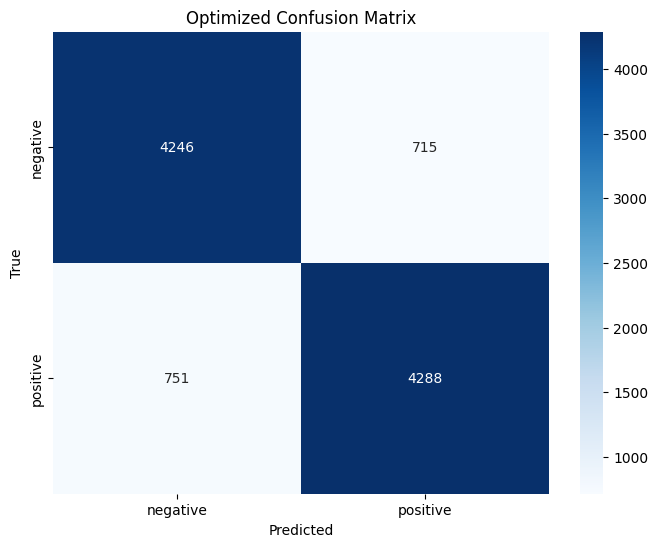

In [ ]:
# Ma trận nhầm lẫn cho mô hình tối ưu
conf_matrix_best = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_best, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Optimized Confusion Matrix')
plt.show()

In [ ]:
#Hàm dự đoán cảm xúc của câu nói
def predict_sentiment(text):
    # Tải lại mô hình và vectorizer
    model = joblib.load('sentiment_model.pkl')
    vectorizer = joblib.load('vectorizer.pkl')

    # Chuyển câu nói thành vector TF-IDF
    text_tfidf = vectorizer.transform([text])

    # Dự đoán cảm xúc
    prediction = model.predict(text_tfidf)

    # Chuyển dự đoán về dạng văn bản (positive/negative)
    sentiment = 'positive' if prediction == 1 else 'negative'

    return sentiment

# 6. Đoạn mã để nhận đầu vào từ người dùng và phân tích cảm xúc
while True:
    text_input = input("Nhập vào câu nói: ")
    if text_input.lower() == 'exit':
        break
    sentiment = predict_sentiment(text_input)
    print(f"Cảm xúc của câu nói đó là: {sentiment}")

In [ ]:
!pip install flask-ngrok
!pip install flask
